# Exploration notebook
This is for Phase 4 of the project.
The data pipeline is ready

In [5]:
# First disconnect from the scanner test
ib.disconnect()

In [3]:
# Wikipedia scrape
import pandas as pd
import requests

url = 'https://en.wikipedia.org/wiki/Russell_1000_Index'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

from io import StringIO

tables = pd.read_html(StringIO(response.text))
for i, t in enumerate(tables):
    print(f"Table {i}: {t.shape}, columns: {list(t.columns)[:5]}")

Table 0: (10, 2), columns: [0, 1]
Table 1: (2, 3), columns: ['Category', 'All-time highs[2]', 'All-time highs[2].1']
Table 2: (31, 3), columns: ['Year', 'Price return', 'Total return']
Table 3: (1005, 4), columns: ['Company', 'Symbol', 'GICS Sector', 'GICS Sub-Industry']
Table 4: (1, 2), columns: ['vteMajor United States stock market indices', 'vteMajor United States stock market indices.1']
Table 5: (8, 2), columns: ['vteMajor North and South American stock market indices', 'vteMajor North and South American stock market indices.1']


In [4]:
russell1000 = tables[3]
print(russell1000.head())
print(f"\n{russell1000['GICS Sector'].nunique()} sectors")
print(russell1000['GICS Sector'].value_counts())

               Company Symbol  GICS Sector         GICS Sub-Industry
0                   3M    MMM  Industrials  Industrial Conglomerates
1          A. O. Smith    AOS  Industrials         Building Products
2                 AAON   AAON  Industrials         Building Products
3  Abbott Laboratories    ABT  Health Care     Health Care Equipment
4               AbbVie   ABBV  Health Care           Pharmaceuticals

11 sectors
GICS Sector
Industrials               171
Financials                153
Information Technology    144
Consumer Discretionary    124
Health Care               107
Real Estate                63
Consumer Staples           60
Materials                  57
Communication Services     49
Utilities                  41
Energy                     36
Name: count, dtype: int64


In [11]:
# check for tickers with dots as it may mess with IB API
dot_tickers = russell1000[russell1000['Symbol'].str.contains(r'\.', na=False)]
print(dot_tickers[['Company', 'Symbol']])

                       Company  Symbol
117         Berkshire Hathaway   BRK.B
149     Brown–Forman (Class A)    BF.A
150     Brown–Forman (Class B)    BF.B
213  Clearway Energy (Class A)  CWEN.A
443            HEICO (Class A)   HEI.A
539           Lennar (Class B)   LEN.B
904          U-Haul (Series N)  UHAL.B


In [14]:
russell1000.to_csv('/Users/hugo/quant-research/config/russell1000_sectors.csv', index=False)

In [12]:
import yaml
with open("/Users/hugo/quant-research/config/equity_universes.yaml", 'r') as f:
    config = yaml.safe_load(f)
universe = 'russell1000'

tickers = config[universe]
print(tickers)
print(len(tickers))

['MMM', 'AOS', 'AAON', 'ABT', 'ABBV', 'ACHC', 'ACN', 'AYI', 'ADBE', 'ADT', 'WMS', 'AMD', 'ACM', 'AES', 'AMG', 'AFRM', 'AFL', 'AGCO', 'A', 'ADC', 'AGNC', 'AL', 'APD', 'ABNB', 'AKAM', 'ALK', 'ALB', 'ACI', 'AA', 'ARE', 'ALGN', 'ALLE', 'ALGM', 'LNT', 'ALSN', 'ALL', 'ALLY', 'ALNY', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'DOX', 'AMTM', 'AS', 'AEE', 'AAL', 'AEP', 'AXP', 'AFG', 'AMH', 'AIG', 'AMT', 'AWK', 'COLD', 'AMP', 'AME', 'AMGN', 'AMKR', 'APH', 'ADI', 'AU', 'NLY', 'AM', 'AR', 'AON', 'APA', 'APG', 'APLS', 'APO', 'APPF', 'AAPL', 'AIT', 'AMAT', 'APP', 'ATR', 'APTV', 'ARMK', 'ACGL', 'ADM', 'ARES', 'ANET', 'AWI', 'ARW', 'AJG', 'ASH', 'AIZ', 'AGO', 'ALAB', 'ASTS', 'T', 'ATI', 'TEAM', 'ATO', 'AUR', 'ADSK', 'ADP', 'AN', 'AZO', 'AVB', 'AVTR', 'AVY', 'CAR', 'AVT', 'AXTA', 'AXS', 'AXON', 'BKR', 'BALL', 'BAC', 'OZK', 'BBWI', 'BAX', 'BDX', 'BRBR', 'BSY', 'BRK B', 'BBY', 'BILL', 'BIO', 'TECH', 'BIIB', 'BMRN', 'BIRK', 'BJ', 'BLK', 'BX', 'HRB', 'XYZ', 'OWL', 'BK', 'BA', 'BOKF', 'BKNG', 'BAH', 'BWA', 'SAM

In [17]:
idx=tickers.index(True)
idx,tickers[idx]

ValueError: True is not in list

In [1]:
# trying the Russell 1000 universe
import nest_asyncio
nest_asyncio.apply()

from src.data_pipelines.run_backfill import run_backfill

run_backfill(
    universe='russell1000',
    start_date='2023-01-01',
    end_date='2026-03-09'
)

INFO:ib_insync.client:Connecting to 127.0.0.1:7497 with clientId 1...
INFO:ib_insync.client:Connected
INFO:ib_insync.client:Logged on to server version 176
INFO:ib_insync.client:API connection ready
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:cafarm
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:hfarm
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:eufarmnj
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:cashfarm
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:usfuture
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:afarm
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:usopt.nj
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:jfarm
INFO:ib_insync.wrapper:Warning 2104, reqId -1: Market data farm connection is OK:usfarm.nj
I

## Inspecting a full IB fetch

In [2]:
import pandas as pd
import numpy as np

# Load production file
df_ib = pd.read_parquet('/Users/hugo/quant-research/data/research/russell1000_research.parquet')

print(df_ib.shape)
print(df_ib.dtypes)
print(df_ib.head())
print(df_ib.index.min(), df_ib.index.max())

(780803, 8)
Open        float64
High        float64
Low         float64
Close       float64
Volume      float64
ticker          str
return      float64
outliers       bool
dtype: object
              Open    High     Low   Close     Volume ticker    return  \
date                                                                     
2023-01-03  151.96  153.13  148.47  150.04   601523.0      A       NaN   
2023-01-04  151.65  153.04  150.24  151.67   667550.0      A  0.010864   
2023-01-05  150.00  153.07  148.77  152.11   848004.0      A  0.002901   
2023-01-06  154.36  154.64  143.01  147.67  1510604.0      A -0.029189   
2023-01-09  149.69  151.28  147.19  147.47   549298.0      A -0.001354   

            outliers  
date                  
2023-01-03     False  
2023-01-04     False  
2023-01-05     False  
2023-01-06     False  
2023-01-09     False  
2023-01-03 00:00:00 2026-03-09 00:00:00


In [25]:
# Look at ticker coverage
print(f"number of unique ticker is {df_ib['ticker'].nunique()}")

price_columns = ['Open','High','Low','Close']
tickers_allnan = df_ib[price_columns].isna().groupby(df_ib['ticker']).all().all(axis=1)
tickers_allnan = tickers_allnan[tickers_allnan].index.tolist()
if tickers_allnan: print(f"The following tickers have only NaN values:\n{tickers_allnan}")
else: print("No single ticker has only NaN values")

# distribution of tickers' observations
obs_per_ticker = df_ib.groupby('ticker')['Close'].count()
print(f"Information of the distribution of observations by tickers:")
print(obs_per_ticker.describe())

# distribution of NaN values per ticker
tickers_nan = df_ib.groupby(['ticker'])['Close'].apply(lambda x: x.isna().sum())
print(f"Information of the distribution of NaNs by tickers:")
print(tickers_nan.describe())

number of unique ticker is 1005
No single ticker has only NaN values
Information of the distribution of observations by tickers:
count    1005.000000
mean      776.918408
std        98.349351
min        45.000000
25%       797.000000
50%       797.000000
75%       797.000000
max       797.000000
Name: Close, dtype: float64
Information of the distribution of NaNs by tickers:
count    1005.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Close, dtype: float64


Note: the NaN distribution is degenerate and that's normal: IB fetches data only if it has a full bar, so the relevant measure is the observation count

In [27]:
max_coverage = obs_per_ticker.max()
coverage_pct = obs_per_ticker / max_coverage * 100
print(coverage_pct.describe())

# How many tickers have full coverage?
print(f"\nTickers with full coverage: {(coverage_pct == 100).sum()}")
print(f"Tickers with >95% coverage: {(coverage_pct >= 95).sum()}")
print(f"Tickers with <50% coverage: {(coverage_pct < 50).sum()}")

count    1005.000000
mean       97.480352
std        12.339944
min         5.646173
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: Close, dtype: float64

Tickers with full coverage: 948
Tickers with >95% coverage: 955
Tickers with <50% coverage: 24


In [28]:
low_coverage = obs_per_ticker[obs_per_ticker / max_coverage < 0.5]
print(low_coverage.sort_values())

ticker
PNFP      45
VSNT      57
Q         91
SOLS      96
FRMI     109
FIGR     123
BLSH     143
NIQ      158
GLIBA    166
GLIBK    166
RAL      177
CAI      181
CRCL     190
SAIL     267
KRMN     267
SNDK     267
MRP      274
SFD      279
PRMB     330
MDU      335
ECG      340
INGM     342
SARO     358
AMTM     364
Name: Close, dtype: int64


## Basic momentum strategy

In [4]:
import pandas as pd
import numpy as np

# Load production file
df_ib = pd.read_parquet('/Users/hugo/quant-research/data/research/russell1000_research.parquet')

print(df_ib.shape)
print(df_ib.dtypes)
print(df_ib.head())
print(df_ib.index.min(), df_ib.index.max())

(780803, 8)
Open        float64
High        float64
Low         float64
Close       float64
Volume      float64
ticker          str
return      float64
outliers       bool
dtype: object
              Open    High     Low   Close     Volume ticker    return  \
date                                                                     
2023-01-03  151.96  153.13  148.47  150.04   601523.0      A       NaN   
2023-01-04  151.65  153.04  150.24  151.67   667550.0      A  0.010864   
2023-01-05  150.00  153.07  148.77  152.11   848004.0      A  0.002901   
2023-01-06  154.36  154.64  143.01  147.67  1510604.0      A -0.029189   
2023-01-09  149.69  151.28  147.19  147.47   549298.0      A -0.001354   

            outliers  
date                  
2023-01-03     False  
2023-01-04     False  
2023-01-05     False  
2023-01-06     False  
2023-01-09     False  
2023-01-03 00:00:00 2026-03-09 00:00:00


In [5]:
import src.data_pipelines.features_equities as feat
# Build features and save the updated data
df_ib = df_ib.copy()
df_ib = feat.add_momentum_features(df_ib)

# bespoke momentum: standard momentum (last year except last month), and short-term reversal
bespoke_momentum_params = [(21, 252), (1, 21)]
for k, p in bespoke_momentum_params:
    df_ib = feat.add_bespoke_momentum(df_ib, k, p)

df_ib = feat.add_volume_features(df_ib)
df_ib = feat.add_volatility_features(df_ib)
df_ib = feat.add_mean_rev_features(df_ib)

print(df_ib.tail())

              Open    High     Low   Close     Volume ticker    return  \
date                                                                     
2026-03-03  127.50  127.90  125.18  125.93  1627390.0    ZTS -0.023496   
2026-03-04  125.91  126.90  124.83  125.96  3182950.0    ZTS  0.000238   
2026-03-05  124.54  125.45  122.04  122.23  2254607.0    ZTS -0.029613   
2026-03-06  121.02  121.87  118.28  121.43  2674650.0    ZTS -0.006545   
2026-03-09  119.78  120.38  118.33  120.15  1240608.0    ZTS -0.010541   

            outliers    mom_5d   mom_21d  ...  mom_1_21  volume_ma_21d  \
date                                      ...                            
2026-03-03     False -0.021219  0.008893  ...  0.033168   2.185058e+06   
2026-03-04     False -0.023187  0.008164  ...  0.007924   2.257957e+06   
2026-03-05     False -0.058030 -0.001470  ...  0.029001   2.268217e+06   
2026-03-06     False -0.073760 -0.041594  ... -0.035280   2.279441e+06   
2026-03-09     False -0.068316 -0.051

In [37]:
df_ib['signal_rank'] = df_ib.groupby(df_ib.index)['mom_21_252'].rank(pct=True)

portfolio1 = df_ib[['ticker','mom_21_252','signal_rank']].copy()
# drop all the NaNs

In [33]:
portfolio1 = portfolio1[portfolio1.index.dayofweek == 1].copy()
portfolio1['equal_weight'] = portfolio1

In [41]:
import pandas as pd
import numpy as np
import src.data_pipelines.features_equities as feat

# Load data
df_ib = pd.read_parquet('/Users/hugo/quant-research/data/research/russell1000_research.parquet')

# Build features
df_ib = feat.add_momentum_features(df_ib)
bespoke_momentum_params = [(21, 252), (1, 21)]
for k, p in bespoke_momentum_params:
    df_ib = feat.add_bespoke_momentum(df_ib, k, p)
df_ib = feat.add_volume_features(df_ib)
df_ib = feat.add_volatility_features(df_ib)
df_ib = feat.add_mean_rev_features(df_ib)

# Keep only Tuesdays and drop NaN signals
portfolio1 = df_ib[df_ib.index.dayofweek == 1][['ticker', 'mom_21_252']].copy()
portfolio1 = portfolio1.dropna(subset=['mom_21_252'])

# Rank cross-sectionally and assign quintiles
portfolio1['signal_rank'] = portfolio1.groupby(portfolio1.index)['mom_21_252'].rank(pct=True)
portfolio1['quintile'] = pd.cut(portfolio1['signal_rank'], bins=5, labels=False)

# Compute weights
def compute_weights(group):
    group = group.copy()
    long = group['quintile'] == 4
    short = group['quintile'] == 0
    n_long = long.sum()
    n_short = short.sum()

    group['weight_eq'] = 0.0
    if n_long > 0:
        group.loc[long, 'weight_eq'] = 0.5 / n_long
    if n_short > 0:
        group.loc[short, 'weight_eq'] = -0.5 / n_short

    group['weight_rank'] = 0.0
    if n_long > 0:
        group.loc[long, 'weight_rank'] = (group.loc[long, 'signal_rank'] /
                                          group.loc[long, 'signal_rank'].sum() * 0.5)
    if n_short > 0:
        group.loc[short, 'weight_rank'] = -(group.loc[short, 'signal_rank'] /
                                            group.loc[short, 'signal_rank'].sum() * 0.5)
    return group

portfolio1 = portfolio1.groupby(portfolio1.index, group_keys=False).apply(compute_weights)

# Verify
print(portfolio1.groupby(portfolio1.index)['weight_eq'].sum().describe())
print(portfolio1.groupby(portfolio1.index)['weight_rank'].sum().describe())

count    1.130000e+02
mean    -2.218297e-18
std      1.589137e-17
min     -5.811324e-17
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.153200e-17
Name: weight_eq, dtype: float64
count    1.130000e+02
mean    -6.426536e-18
std      7.277100e-17
min     -2.200930e-16
25%     -5.030698e-17
50%      1.734723e-18
75%      4.770490e-17
max      1.561251e-16
Name: weight_rank, dtype: float64


In [1]:
import pandas as pd
import numpy as np
import src.data_pipelines.features_equities as feat

# Load data
df_ib = pd.read_parquet('/Users/hugo/quant-research/data/research/russell1000_research.parquet')
print(f"shape: {df_ib.shape}, number of years: {df_ib.shape[0] / (252 * df_ib['ticker'].nunique())}")

# Build features
df_ib = feat.add_momentum_features(df_ib)
bespoke_momentum_params = [(21, 252), (1, 21)]
for k, p in bespoke_momentum_params:
    df_ib = feat.add_bespoke_momentum(df_ib, k, p)
df_ib = feat.add_volume_features(df_ib)
df_ib = feat.add_volatility_features(df_ib)
df_ib = feat.add_mean_rev_features(df_ib)

# drop NaN rows from momentum measures computation
df_ib = df_ib.dropna(subset=['mom_21_252'])
print(f"shape: {df_ib.shape}, number of years: {df_ib.shape[0] / (252 * df_ib['ticker'].nunique())}")

# compute rank and corresponding quintiles
df_ib['rank'] = df_ib['mom_21_252'].groupby(df_ib.index).rank()

df_ib['quintile'] = df_ib['rank'].groupby(df_ib.index).transform(lambda x: pd.qcut(x, q=5, labels=[1, 2, 3, 4, 5]))

# compute signal based on quintiles
df_ib['signal'] = 1*(df_ib['quintile'] == 5) - 1*(df_ib['quintile'] == 1)

# compute weights

# create mask for shorts and longs
mask_short = df_ib['signal'] == -1
mask_long = df_ib['signal'] == 1

# equal weighting
n_short = mask_short.groupby(df_ib.index).transform('sum')
n_long = mask_long.groupby(df_ib.index).transform('sum')

df_ib['w_eq'] = 0.0
df_ib.loc[mask_short,'w_eq'] = -0.5 / n_short[mask_short]
df_ib.loc[mask_long,'w_eq'] = 0.5 / n_long[mask_long]

# standardized weighting
df_ib['z'] = df_ib['rank'].groupby(df_ib.index).transform(lambda x: (x - x.mean()) / x.std())

z_short = df_ib['z'].where(mask_short,0)
z_long = df_ib['z'].where(mask_long,0)

sum_short = z_short.groupby(df_ib.index).transform('sum')
sum_long = z_long.groupby(df_ib.index).transform('sum')

# standardized weights
df_ib['w_stdz'] = 0.0
df_ib.loc[mask_short,'w_stdz'] = -0.5 * z_short[mask_short] / sum_short[mask_short]
df_ib.loc[mask_long,'w_stdz'] = 0.5 * z_long[mask_long] / sum_long[mask_long]


shape: (780803, 8), number of years: 3.083009555397615
shape: (529117, 23), number of years: 2.1166034626216077


In [2]:
# check weights
print("Equal weights:")
print(f"overall sum: {df_ib.groupby(df_ib.index)['w_eq'].sum().mean()}")
print(f"sum of longs: {df_ib.loc[mask_long,'w_eq'].groupby(df_ib.loc[mask_long].index).sum().mean()}")
print(f"sum of shorts: {df_ib.loc[mask_short,'w_eq'].groupby(df_ib.loc[mask_short].index).sum().mean()}")

print("\nStandardized weights:")
print(f"overall sum: {df_ib.groupby(df_ib.index)['w_stdz'].sum().mean()}")
print(f"sum of longs: {df_ib.loc[mask_long,'w_stdz'].groupby(df_ib.loc[mask_long].index).sum().mean()}")
print(f"sum of shorts: {df_ib.loc[mask_short,'w_stdz'].groupby(df_ib.loc[mask_short].index).sum().mean()}")

Equal weights:
overall sum: 2.5042086141738586e-18
sum of longs: 0.5
sum of shorts: -0.5

Standardized weights:
overall sum: -4.825793816541902e-18
sum of longs: 0.5
sum of shorts: -0.5


In [4]:
# create rebalancing dates and compute weekly portfolio returns
df_ib['rebalance'] = df_ib.index.where(df_ib.index.dayofweek == 1)
df_ib['week_index'] = df_ib.groupby('ticker')['rebalance'].ffill()
df_ib = df_ib.dropna(subset=['week_index'])

# assign equal weights within each rebalancing week
# compute weekly returns and collapse dataset weekly
df_ib['weekly_ret'] = df_ib.groupby(['ticker','week_index'])['return'].transform(lambda x: (1+x).prod() - 1)

df_ib_weekly = df_ib.loc[df_ib.index.dayofweek == 1,['weekly_ret','w_eq','w_stdz','signal','ticker']].copy()
df_ib_weekly['ret_eq'] = df_ib_weekly['w_eq'] * df_ib_weekly['weekly_ret']
df_ib_weekly['ret_stdz'] = df_ib_weekly['w_stdz'] * df_ib_weekly['weekly_ret']

# compute costs
df_ib_weekly['w_eq_prev'] = df_ib_weekly.groupby('ticker')['w_eq'].shift(1).fillna(0)
df_ib_weekly['w_stdz_prev'] = df_ib_weekly.groupby('ticker')['w_stdz'].shift(1).fillna(0)

df_ib_weekly['turnover_eq'] = (df_ib_weekly['w_eq'] - df_ib_weekly['w_eq_prev']).abs()
df_ib_weekly['turnover_stdz'] = (df_ib_weekly['w_stdz'] - df_ib_weekly['w_stdz_prev']).abs()

cost_per_unit = 0.001
df_ib_weekly['ret_eq'] = df_ib_weekly['ret_eq'] - cost_per_unit * df_ib_weekly['turnover_eq']
df_ib_weekly['ret_stdz'] = df_ib_weekly['ret_stdz'] - cost_per_unit * df_ib_weekly['turnover_stdz']

# strategy return
strategy = df_ib_weekly.groupby(df_ib_weekly.index)[['ret_eq', 'ret_stdz']].sum()
strategy.columns = ['ret_eq_w', 'ret_stdz_w']

print(strategy.shape)
print(f"Equal weights strategy return: {((1 + strategy['ret_eq_w']).prod() - 1)*100:.2f}%")
print(f"Standardized weights strategy return: {((1 + strategy['ret_stdz_w']).prod() - 1)*100:.2f}%")

(113, 2)
Equal weights strategy return: 19.35%
Standardized weights strategy return: 20.80%


In [5]:
# Annualization factor (52 weeks per year)
ann = 52

# Annualized return
ann_ret_eq = (1 + strategy['ret_eq_w']).prod() ** (ann / len(strategy)) - 1
ann_ret_stdz = (1 + strategy['ret_stdz_w']).prod() ** (ann / len(strategy)) - 1

# Annualized volatility
ann_vol_eq = strategy['ret_eq_w'].std() * np.sqrt(ann)
ann_vol_stdz = strategy['ret_stdz_w'].std() * np.sqrt(ann)

# Sharpe ratio (assuming 0 risk-free rate for simplicity)
sharpe_eq = ann_ret_eq / ann_vol_eq
sharpe_stdz = ann_ret_stdz / ann_vol_stdz

print(f"Equal weights:      Ann. return: {ann_ret_eq*100:.2f}%  Vol: {ann_vol_eq*100:.2f}%  Sharpe: {sharpe_eq:.2f}")
print(f"Standardized weights: Ann. return: {ann_ret_stdz*100:.2f}%  Vol: {ann_vol_stdz*100:.2f}%  Sharpe: {sharpe_stdz:.2f}")

Equal weights:      Ann. return: 8.48%  Vol: 9.00%  Sharpe: 0.94
Standardized weights: Ann. return: 9.09%  Vol: 9.37%  Sharpe: 0.97


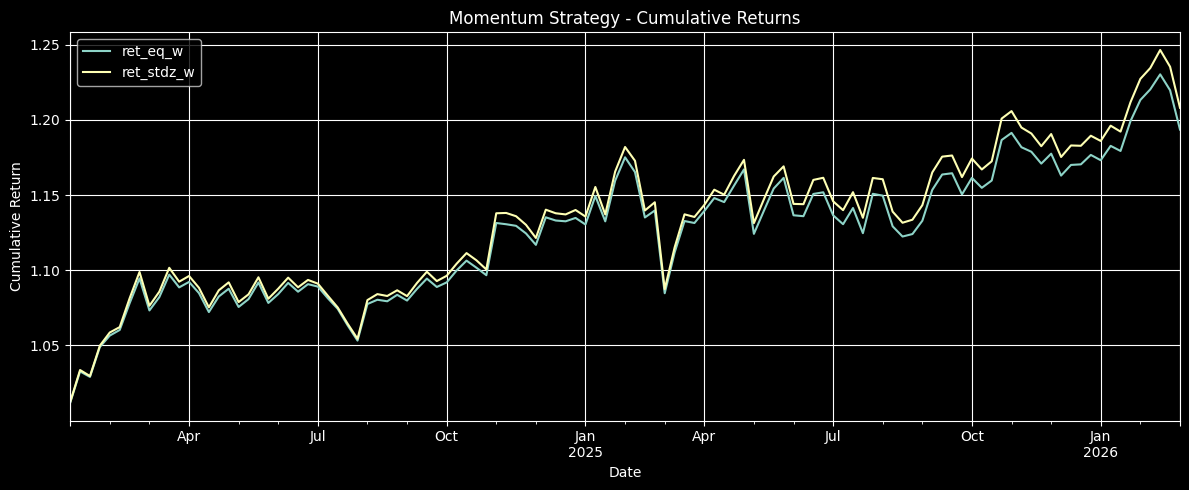

In [6]:
import matplotlib.pyplot as plt

cumret = (1 + strategy).cumprod()
cumret.plot(figsize=(12, 5), title='Momentum Strategy - Cumulative Returns')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def backtest_ls_strategy(df, signal_col, long_leg):
    """
    Simple long/short quintile backtest.
    Args:
        df: daily DataFrame with date index, ticker column, return column, and signal column
        signal_col: name of the signal column to use
        long_leg: quintile for long position (the short being the opposite of the distribution)
    Returns:
        strategy: weekly DataFrame with net returns
        metrics: dict with annualized return, vol, sharpe
    """
    # compute rank and corresponding quintiles
df_ib['rank'] = df_ib['mom_21_252'].groupby(df_ib.index).rank()

df_ib['quintile'] = df_ib['rank'].groupby(df_ib.index).transform(lambda x: pd.qcut(x, q=5, labels=[1, 2, 3, 4, 5]))

# compute signal based on quintiles
df_ib['signal'] = 1*(df_ib['quintile'] == 5) - 1*(df_ib['quintile'] == 1)

# compute weights

# create mask for shorts and longs
mask_short = df_ib['signal'] == -1
mask_long = df_ib['signal'] == 1

# equal weighting
n_short = mask_short.groupby(df_ib.index).transform('sum')
n_long = mask_long.groupby(df_ib.index).transform('sum')

df_ib['w_eq'] = 0.0
df_ib.loc[mask_short,'w_eq'] = -0.5 / n_short[mask_short]
df_ib.loc[mask_long,'w_eq'] = 0.5 / n_long[mask_long]

# standardized weighting
df_ib['z'] = df_ib['rank'].groupby(df_ib.index).transform(lambda x: (x - x.mean()) / x.std())

z_short = df_ib['z'].where(mask_short,0)
z_long = df_ib['z'].where(mask_long,0)

sum_short = z_short.groupby(df_ib.index).transform('sum')
sum_long = z_long.groupby(df_ib.index).transform('sum')

# standardized weights
df_ib['w_stdz'] = 0.0
df_ib.loc[mask_short,'w_stdz'] = -0.5 * z_short[mask_short] / sum_short[mask_short]
df_ib.loc[mask_long,'w_stdz'] = 0.5 * z_long[mask_long] / sum_long[mask_long]